# Linear Regression 

### STEP 1 — IMPORT LIBRARIES

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### STEP 2 — LOAD DATA

In [2]:

df=pd.read_csv("lr_data1.csv")

In [3]:
df.shape

(100, 4)

### STEP 3 — UNDERSTAND THE DATA

In [4]:
print(df.head())

   EmployeeID       EmployeeName  YearsExperience  Salary
0           1         Judith Orr              7.2   63108
1           2  Melissa Alexander             13.9   95296
2           3       Jeremy Davis             13.1   90394
3           4   Jay Stafford DVM             13.2   92803
4           5      Shawn Mcclain             10.0   73634


In [6]:
print(df.tail())

    EmployeeID        EmployeeName  YearsExperience  Salary
95          96     Jessica Collins             10.3   75150
96          97        Eric Johnson              8.9   68651
97          98    Melissa Shepherd              2.1   33129
98          99       Michael Parks              8.6   70768
99         100  Christopher Nelson              2.6   36338


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EmployeeID       100 non-null    int64  
 1   EmployeeName     100 non-null    object 
 2   YearsExperience  100 non-null    float64
 3   Salary           100 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 3.3+ KB
None


In [8]:
print(df.describe())

       EmployeeID  YearsExperience        Salary
count  100.000000       100.000000    100.000000
mean    50.500000         8.473000  67298.520000
std     29.011492         3.857928  19528.084848
min      1.000000         1.000000  29328.000000
25%     25.750000         6.050000  54706.000000
50%     50.500000         8.150000  66773.500000
75%     75.250000        11.825000  84186.000000
max    100.000000        14.800000  99749.000000


### STEP 4 — CHECK MISSING VALUES

In [9]:

print(df.isnull().sum())

EmployeeID         0
EmployeeName       0
YearsExperience    0
Salary             0
dtype: int64


### STEP 5 — DATA VISUALIZATION

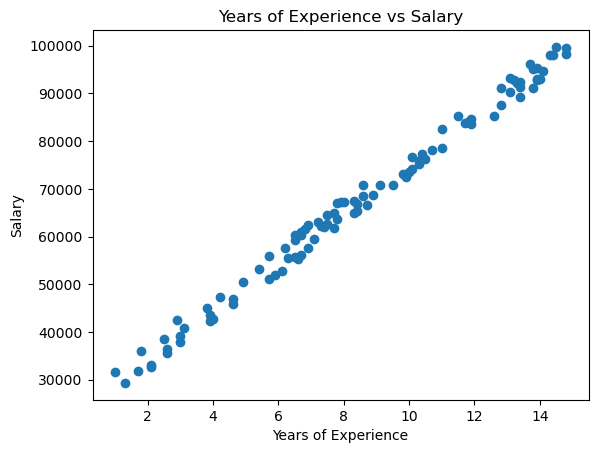

In [10]:

plt.scatter(df['YearsExperience'], df['Salary'])
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

### STEP 6 — DEFINE X AND Y(Feature and Target)

In [11]:

X = df[['YearsExperience']]
Y = df['Salary']
print(X)
print(Y)

    YearsExperience
0               7.2
1              13.9
2              13.1
3              13.2
4              10.0
..              ...
95             10.3
96              8.9
97              2.1
98              8.6
99              2.6

[100 rows x 1 columns]
0     63108
1     95296
2     90394
3     92803
4     73634
      ...  
95    75150
96    68651
97    33129
98    70768
99    36338
Name: Salary, Length: 100, dtype: int64


### STEP 7 — SPLIT DATA

In [13]:

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.2, random_state=42)

In [14]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", Y_train.shape)
print("y_test shape:", Y_test.shape)

X_train shape: (80, 1)
X_test shape: (20, 1)
y_train shape: (80,)
y_test shape: (20,)


### STEP 8 — IMPORT MODEL

In [15]:

from sklearn.linear_model import LinearRegression

### STEP 9 — CREATE MODEL

In [16]:

model = LinearRegression()

### STEP 10 — TRAIN MODEL

In [17]:

model.fit(X_train, Y_train)



LinearRegression()

### STEP 11 — MODEL DETAILS

In [18]:

print("Intercept:", model.intercept_)
print("Coefficient/slope:", model.coef_)



Intercept: 24725.53576355354
Coefficient/slope: [5031.36410473]


### STEP 12 — MAKE PREDICTIONS

In [19]:

Y_pred = model.predict(X_test)

print(Y_pred)



[68498.40347466 83592.49578884 57429.40244427 59441.94808616
 95667.76964018 31266.3090997  76548.58604222 67995.26706419
 66485.85783277 60951.35731757 57429.40244427 54410.58398143
 63970.17578041 64473.31219088 92145.81476687 75039.1768108
 53404.31116049 47869.81064529 77051.72245269 58435.67526521]


### STEP 13 — COMPARE ACTUAL VS PREDICTED

In [20]:

comparison = pd.DataFrame({
    'Actual Salary': Y_test,
    'Predicted Salary': Y_pred
})

print(comparison)



    Actual Salary  Predicted Salary
83          66619      68498.403475
53          83854      83592.495789
70          60268      57429.402444
45          57517      59441.948086
44          94622      95667.769640
39          29328      31266.309100
22          75897      76548.586042
80          68560      67995.267064
10          67451      66485.857833
0           63108      60951.357318
18          55808      57429.402444
30          52050      54410.583981
73          63616      63970.175780
33          67288      64473.312191
90          91424      92145.814767
4           73634      75039.176811
76          51198      53404.311160
77          45878      47869.810645
12          77288      77051.722453
31          60923      58435.675265


### STEP 14 — VISUALIZE REGRESSION LINE

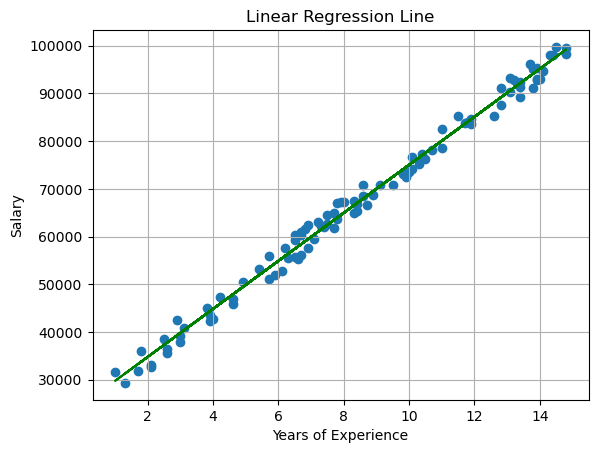

In [24]:

plt.scatter(X, Y)
plt.plot(X, model.predict(X),color='green')

plt.title("Linear Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.grid()
plt.show()



### STEP 15 — MODEL EVALUATION

In [25]:

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import r2_score

mae = mean_absolute_error(Y_test, Y_pred)#Average absolute difference between actual and predicted values.
mse = mean_squared_error(Y_test, Y_pred)#Average of squared errors
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)#How much variance in data is explained by the model

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)




MAE: 1521.310078802158
MSE: 3018142.655568051
RMSE: 1737.2802466982841
R2 Score: 0.986530116794866


### STEP 16 — PREDICT NEW VALUE

In [27]:
new_prediction = model.predict([[12]])
print(new_prediction)


print("Predicted Salary for 12 Years Experience:",new_prediction[0])

# STEP 17 — CONCLUSION
print("Linear Regression model built successfully.")

[85101.90502025]
Predicted Salary for 12 Years Experience: 85101.9050202542
Linear Regression model built successfully.


C:\Users\Anju\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
